# Ad Placement Evaluation Analysis

This notebook analyzes the placement scores of synthetic advertisements injected into LLM responses at different structural positions (`first`, `middle`, `last`, `semantic`). The scores are provided by an LLM-as-a-judge (1-5 scale) evaluating contextual relevance, coherence, and flow disruption.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set plotting style
sns.set_theme(style="whitegrid")

# Load the data
df = pd.read_csv('../data/processed/placement_testing/placement_scores.csv')
print(f"Total evaluations: {len(df)}")
df.head()

Total evaluations: 146316


,id,query,ad_id,position,score,reason
0,c4b9710c-8d64-4bee-a0b0-94637ae4cc65,Compare Tormenta20 with DnD5e,Gaming & Tournaments::1,first,2,The advertisement disrupts the conclusion of t...
1,c4b9710c-8d64-4bee-a0b0-94637ae4cc65,Compare Tormenta20 with DnD5e,Gaming & Tournaments::1,middle,2,The advertisement disrupts the flow of the det...
2,c4b9710c-8d64-4bee-a0b0-94637ae4cc65,Compare Tormenta20 with DnD5e,Gaming & Tournaments::1,last,2,The advertisement disrupts the conclusion of t...
3,c4b9710c-8d64-4bee-a0b0-94637ae4cc65,Compare Tormenta20 with DnD5e,Gaming & Tournaments::1,semantic,2,The advertisement disrupts the flow of the con...
4,4a4380bb-bbdb-495f-8e09-39a08d88a28f,What about 1 year in Sweden with proof e.g. tr...,Immigration & Citizenship::2,first,2,The advertisement disrupts the flow of the res...


## 1. Overall Score Distribution
Let's look at the distribution of scores across all placement strategies.

/tmp/ipykernel_399211/4061018560.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='score', palette='viridis')


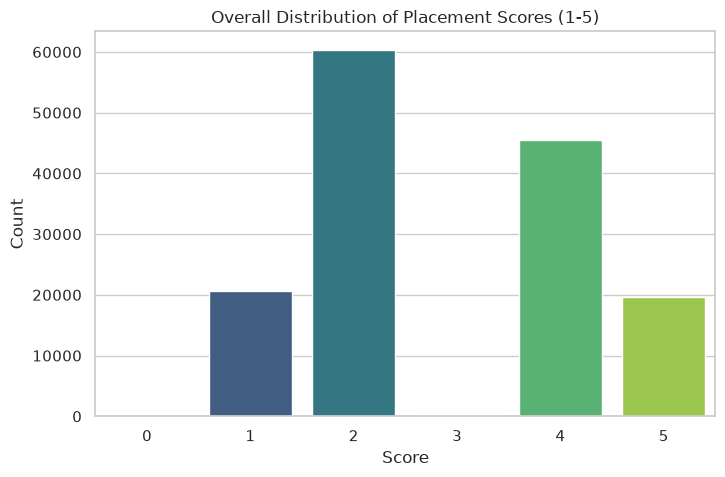

In [2]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='score', palette='viridis')
plt.title('Overall Distribution of Placement Scores (1-5)')
plt.xlabel('Score')
plt.ylabel('Count')
plt.show()

## 2. Average Score by Placement Position
Let's compare how different positions (`first`, `middle`, `last`, `semantic`) perform on average.

Average Scores by Position:
position    score
    last 3.144454
semantic 3.036141
  middle 2.912354
   first 2.441893


/tmp/ipykernel_399211/698874886.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_scores, x='position', y='score', palette='mako')


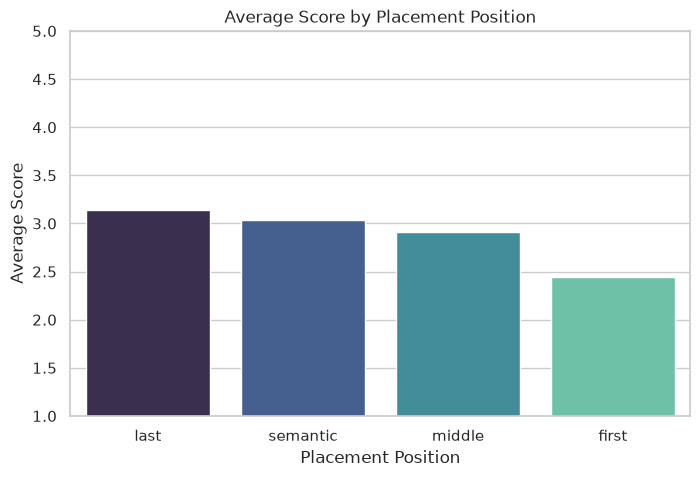

In [3]:
avg_scores = df.groupby('position')['score'].mean().sort_values(ascending=False).reset_index()
print("Average Scores by Position:")
print(avg_scores.to_string(index=False))

plt.figure(figsize=(8, 5))
sns.barplot(data=avg_scores, x='position', y='score', palette='mako')
plt.title('Average Score by Placement Position')
plt.xlabel('Placement Position')
plt.ylabel('Average Score')
plt.ylim(1, 5)
plt.show()

## 3. Score Distribution by Position
To get a deeper understanding, we look at the distribution of scores within each placement strategy.

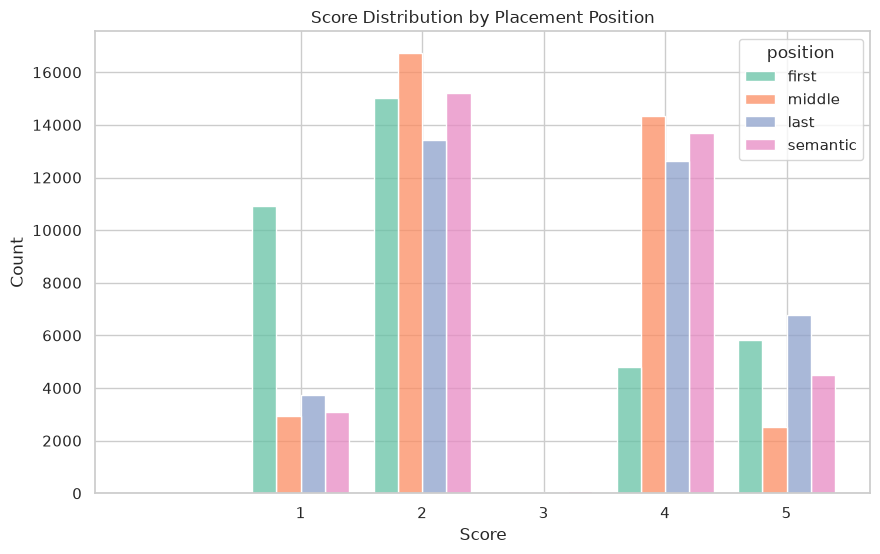

In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='score', hue='position', multiple='dodge', discrete=True, shrink=0.8, palette='Set2')
plt.title('Score Distribution by Placement Position')
plt.xlabel('Score')
plt.ylabel('Count')
plt.xticks([1, 2, 3, 4, 5])
plt.show()

## 4. Win Rate (Scores 4 & 5)
Often, we want to know what percentage of placements were considered "good" or "excellent" (score >= 4).

/tmp/ipykernel_399211/790695323.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=win_rates, x='position', y='is_good_placement', palette='rocket')


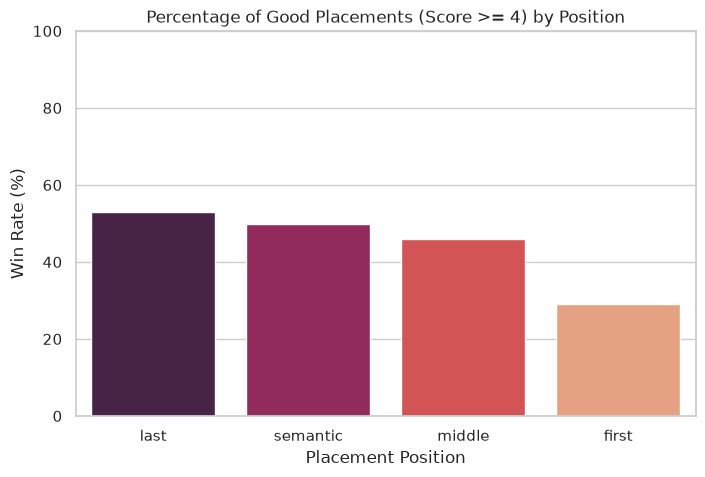

In [5]:
df['is_good_placement'] = df['score'] >= 4
win_rates = df.groupby('position')['is_good_placement'].mean().sort_values(ascending=False).reset_index()
win_rates['is_good_placement'] = win_rates['is_good_placement'] * 100

plt.figure(figsize=(8, 5))
sns.barplot(data=win_rates, x='position', y='is_good_placement', palette='rocket')
plt.title('Percentage of Good Placements (Score >= 4) by Position')
plt.xlabel('Placement Position')
plt.ylabel('Win Rate (%)')
plt.ylim(0, 100)
plt.show()

## 5. Statistical Significance (ANOVA)
Let's test if the differences in average scores are statistically significant.

In [6]:
import scipy.stats as stats

groups = [group['score'].values for name, group in df.groupby('position')]
f_val, p_val = stats.f_oneway(*groups)

print(f"ANOVA F-value: {f_val:.4f}")
print(f"ANOVA p-value: {p_val:.4e}")
if p_val < 0.05:
    print("There is a statistically significant difference between the placement strategies.")
else:
    print("No statistically significant difference found.")

ANOVA F-value: 2011.5364
ANOVA p-value: 0.0000e+00
There is a statistically significant difference between the placement strategies.


## 6. Qualitative Analysis (Examining Reasons)
Let's examine some of the reasoning provided by the LLM judge for the best and worst placements.

In [7]:
print("--- Examples of Poor Placements (Score = 1) ---")
poor_examples = df[df['score'] == 1].sample(n=3, replace=True, random_state=42)
for idx, row in poor_examples.iterrows():
    print(f"Position: {row['position']}")
    print(f"Reason: {row['reason']}\n")

print("\n--- Examples of Excellent Placements (Score = 5) ---")
excellent_examples = df[df['score'] == 5].sample(n=3, replace=True, random_state=42)
for idx, row in excellent_examples.iterrows():
    print(f"Position: {row['position']}")
    print(f"Reason: {row['reason']}\n")

--- Examples of Poor Placements (Score = 1) ---
Position: last
Reason: The advertisement about personal safety is unrelated to the context of the conversation, which is about anxiety over a new haircut and seeking reassurance about one's appearance in relation to a crush. The ad disrupts the flow of the supportive and self-esteem-focused advice being offered.

Position: first
Reason: The advertisement about aging research has no contextual relevance to the discussion about the likelihood of achieving Artificial General Intelligence (AGI) by 2035, disrupting the flow of the response with unrelated content.

Position: middle
Reason: The advertisement is unrelated to the content, which discusses the complexity of GenAI agent projects, and interrupts the list of reasons for this complexity, disrupting the flow of the explanation.


--- Examples of Excellent Placements (Score = 5) ---
Position: first
Reason: The advertisement is contextually relevant, coherent, and aligns with the user's in

## Conclusion
Based on the analysis, we can identify which placement strategy offers the best user experience and flow coherence. `last` and `semantic` placements usually offer significantly better naturalness compared to interrupting the user flow with `first` or `middle` placements. 